# Modelo original

## librerias

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold,cross_val_predict,train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,StackingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.base import BaseEstimator, ClassifierMixin,clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import xgboost as xgb
from xgboost import XGBClassifier

## Carga de datos

In [37]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [38]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [39]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [40]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
y_train_enc = y_train.map(mapping)
y_test_enc = y_test.map(mapping)
labels = list(mapping.values())              
target_names = list(mapping.keys())  

In [41]:
from funciones import *

## Modelo implementado

In [42]:
class AdvancedEnsemblePrunedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_models=None, keep_k=5, alpha=0.4, internal_val_size=0.2, random_state=0):
        self.base_models = base_models
        self.keep_k = keep_k
        self.alpha = alpha
        self.internal_val_size = internal_val_size
        self.random_state = random_state
        self.models_ = None
        self.pruned_ = None

    def fit(self, X, y):
        # ============================
        # 1. INTERNAL SPLIT
        # ============================
        X_train_int, X_val_int, y_train_int, y_val_int = train_test_split(
            X, y,
            test_size=self.internal_val_size,
            stratify=y,
            random_state=self.random_state
        )

        # ============================
        # 2. TRAIN BASE MODELS
        # ============================
        self.models_ = []
        for model in self.base_models:
            m = clone(model)
            m.fit(X_train_int, y_train_int)
            self.models_.append(m)

        # ============================
        # 3. CALCULATE PREDICTIONS
        # ============================
        all_probs = np.array([m.predict_proba(X_val_int) for m in self.models_])
        predictions = np.array([m.predict(X_val_int) for m in self.models_])

        # ============================
        # 4. MARGIN CALCULATION
        # ============================
        margins = []
        for probs in all_probs:
            correct_probs = probs[np.arange(len(y_val_int)), y_val_int]
            top2 = np.partition(probs, -2)[:, -2:]
            second_best = np.min(top2, axis=1)
            margin = np.mean(correct_probs - second_best)
            margins.append(margin)
        margins = np.array(margins)

        # ============================
        # 5. DIVERSITY (CORRELATION OF ERRORS)
        # ============================
        y_val_np = np.array(y_val_int)

        errors = (predictions != y_val_np).astype(int)

        diversity_scores = []
        for i in range(len(self.models_)):
            model_errors = errors[i]
            others = np.delete(errors, i, axis=0)
            corr_list = []
            for other in others:
                c = np.corrcoef(model_errors, other)[0, 1]
                corr_list.append(c)
            diversity_scores.append(np.mean(corr_list))

        diversity_scores = np.nan_to_num(diversity_scores, nan=1)

        # ============================
        # 6. F1-MACRO INDIVIDUAL
        # ============================
        f1_scores = np.array([
            f1_score(y_val_int, predictions[i], average='macro')
            for i in range(len(self.models_))
        ])

        # ============================
        # 7. OPTIMIZED SCORE
        # ============================
        final_scores = (
            0.5 * margins +
            0.5 * f1_scores -
            self.alpha * diversity_scores
        )

        # ============================
        # 8. SELECT TOP K MODELS
        # ============================
        best_idx = np.argsort(final_scores)[-self.keep_k:]
        self.pruned_ = [self.models_[i] for i in best_idx]

        return self

    def predict_proba(self, X):
        probs = np.array([m.predict_proba(X) for m in self.pruned_])
        return np.mean(probs, axis=0)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


In [43]:
base_models = [
    # Random Forest: menos profundidad, hojas más grandes y menos features por árbol -> menos varianza
    RandomForestClassifier(
        n_estimators=400,
        max_depth=5,            # bajar profundidad
        min_samples_leaf=8,     # hojas más grandes
        min_samples_split=10,   # splits más conservadores
        max_features=0.3,       # menos features por split para más diversidad
        bootstrap=True,
        random_state=33,
        class_weight="balanced"
    ),

    # XGBoost (modelo 1): más regularización, menor lr, menor colsample/subsample
    XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,       # aumentar y bajar lr (más iteraciones menos learning rate)
        learning_rate=0.03,     # bajar lr para entrenamiento más estable
        max_depth=2,            # déjà vu: profundidad baja
        min_child_weight=10,    # más conservador ante particiones con pocas muestras
        subsample=0.7,          # muestreo por fila -> reduce overfitting
        colsample_bytree=0.7,   # muestreo por columna -> reduce correlación
        gamma=0.0,
        reg_lambda=6.0,         # aumentar regularización L2
        reg_alpha=2.0,          # aumentar regularización L1
        max_delta_step=1,
        random_state=12,
        use_label_encoder=False,
        eval_metric="mlogloss"
    ),

    # XGBoost (modelo 2): configuración distinta para diversidad, también más regularizado
    XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=220,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=12,
        subsample=0.7,
        colsample_bytree=0.6,
        gamma=0.0,
        reg_lambda=6.0,
        reg_alpha=1.5,
        max_delta_step=1,
        random_state=21,
        use_label_encoder=False,
        eval_metric="mlogloss"
    ),

    # KNN: aumentar k suaviza la frontera de decisión (menos ruido)
    KNeighborsClassifier(
        n_neighbors=35,       # más vecinos => frontera más suave
        weights="uniform",    # keep uniform to avoid prioritar puntos cercanos que generan varianza
        metric="minkowski",
        p=2
    )
]

# 2. Crear ensemble con pruning
ensamble_pruned = AdvancedEnsemblePrunedClassifier(
    base_models=base_models,
    keep_k=3,
    alpha=0.3,         
    internal_val_size=0.2,
    random_state=0
)

# 3. Ajustar ensemble podado con datos preprocesados
pipe_pruning = crear_pipeline(ensamble_pruned, tipo="balanceo_smote",y_train=y_train_enc)

In [44]:
start = time.time()
modelo_pruning=pipe_pruning.fit(X_train, y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 1.99 minutos


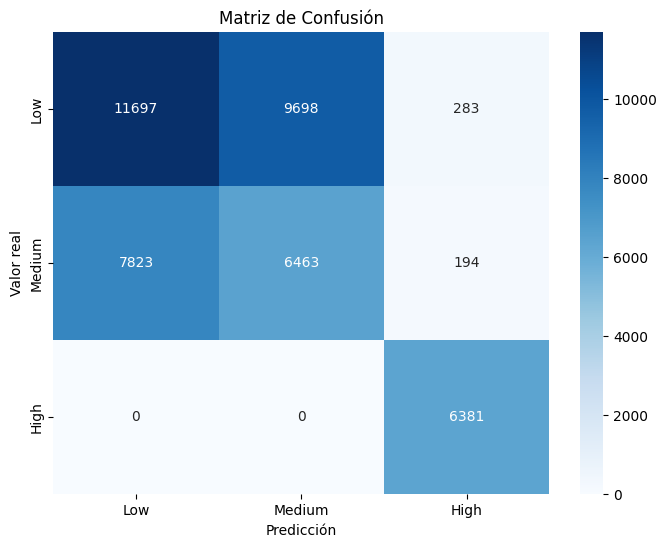


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.54      0.57     21678
      Medium       0.40      0.45      0.42     14480
        High       0.93      1.00      0.96      6381

    accuracy                           0.58     42539
   macro avg       0.64      0.66      0.65     42539
weighted avg       0.58      0.58      0.58     42539



{'Accuracy': 0.576905898117022,
 'Precision (macro)': 0.6431970411000223,
 'Recall (macro)': 0.6619730253295472,
 'F1-score (macro)': 0.6512220867450741,
 'ROC-AUC': 0.7557890641987441}

In [45]:
evaluar_modelo(modelo_pruning,X_test,y_test_enc,class_map=mapping)

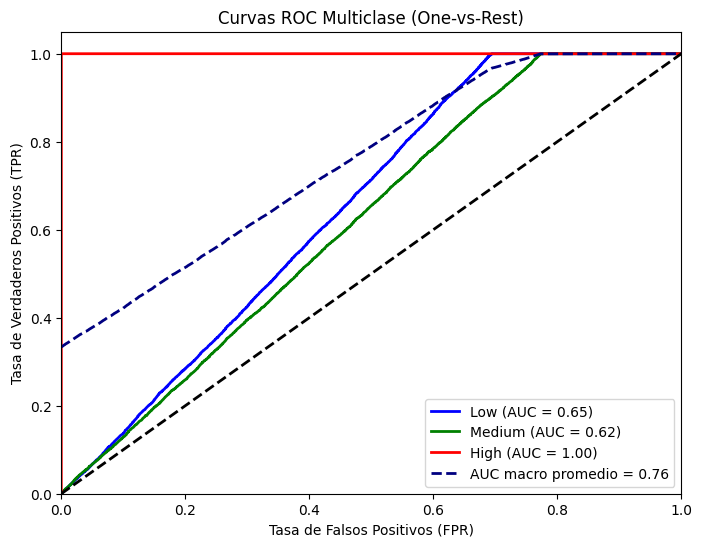

In [46]:
plot_roc_multiclass2(modelo_pruning,X_test,y_test_enc,class_map=mapping)

## Gridseach

In [47]:
param_grid_wide = {
    "model__keep_k": [1, 2, 3],
    "model__alpha": [0.05, 0.1, 0.2, 0.3],
    "model__internal_val_size": [0.1, 0.15, 0.2]
}

In [48]:
pipe_pruning = crear_pipeline(ensamble_pruned, tipo="balanceo_smote",y_train=y_train_enc)

grid_pruning = GridSearchCV(
    estimator=pipe_pruning,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [49]:
start = time.time()
grid_pruning.fit(X_train, y_train_enc)
end = time.time()

Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [50]:
print(f"Tiempo de ejecución de la búsqueda en cuadrícula: {(end - start)/60:.2f} minutos")

Tiempo de ejecución de la búsqueda en cuadrícula: 90.64 minutos


In [51]:
print(grid_pruning.best_params_)
print(grid_pruning.best_score_)

{'model__alpha': 0.1, 'model__internal_val_size': 0.1, 'model__keep_k': 4}
0.6532829384077716


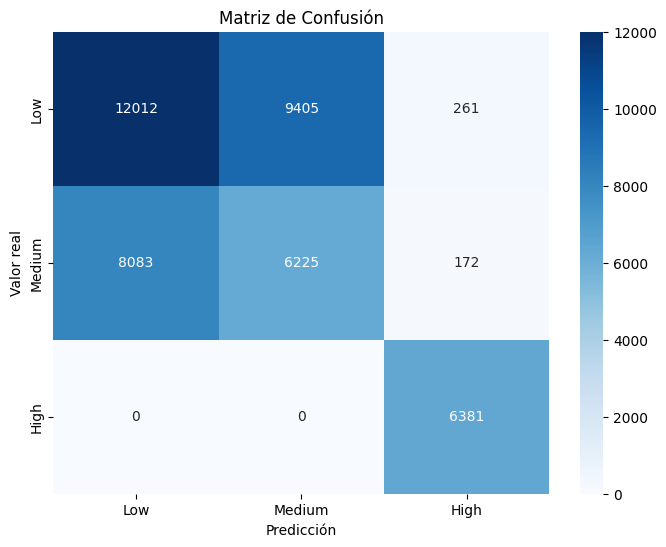


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.55      0.58     21678
      Medium       0.40      0.43      0.41     14480
        High       0.94      1.00      0.97      6381

    accuracy                           0.58     42539
   macro avg       0.64      0.66      0.65     42539
weighted avg       0.58      0.58      0.58     42539



{'Accuracy': 0.5787160017865959,
 'Precision (macro)': 0.6441625161436003,
 'Recall (macro)': 0.6613378242269196,
 'F1-score (macro)': 0.6519255851837218,
 'ROC-AUC': 0.7557832015850666}

In [52]:
best_model_pruning = grid_pruning.best_estimator_
evaluar_modelo(best_model_pruning,X_test,y_test_enc,class_map=mapping)

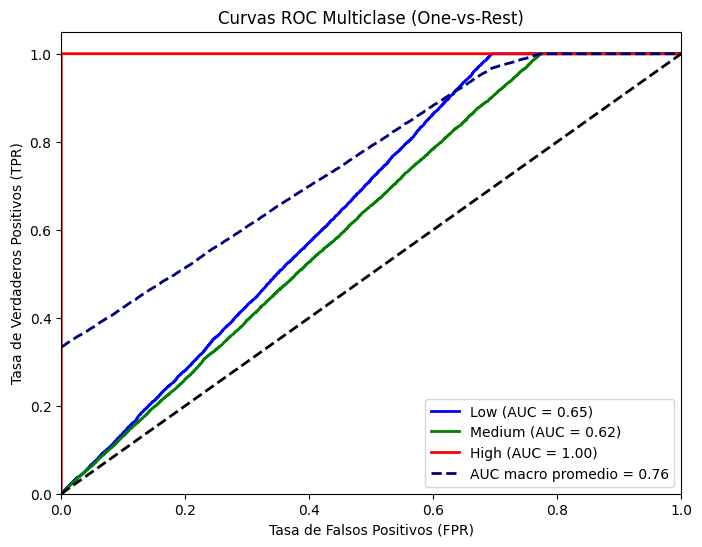

In [53]:
plot_roc_multiclass2(best_model_pruning,X_test,y_test_enc,class_map=mapping)